# Individual Task 2 — Part 2: Deliberation on Task 1

COSC2669/COSC2816 Case Studies in Data Science · Amir Munawar Wangde (s4186051)

This notebook re-examines the Task 1 analysis (OULAD and Student Performance, random forest and MLP)
for **evaluation soundness, learning behaviour and fairness**. It reuses the Task 1 data pipeline unchanged,
so every difference reported here comes from the evaluation design, not from new modelling choices.

| Section | Assignment requirement |
|---|---|
| 1–2 | Rebuild the Task 1 frames |
| 3 | Leakage audit: repeated students, duplicated students, features only known after the outcome |
| 4 | Cross-validation and sampling: single split vs stratified k-fold vs stratified *group* k-fold |
| 5 | Learning curves under varying training-set sizes |
| 6 | Bias analysis with Microsoft Fairlearn (MetricFrame, disparity metrics, unawareness test, ThresholdOptimizer) |
| 7 | Export tables and figures for the LaTeX report |

**Before running:** put `studentInfo.csv`, `studentVle.csv`, `student-mat.csv`, `student-por.csv` in `data/`.
Runtime is roughly 15–30 minutes on a laptop; set `FAST = True` for a quick draft run.

In [1]:
import importlib.util, subprocess, sys
for pkg, mod in [("scikit-learn","sklearn"),("pandas","pandas"),("matplotlib","matplotlib"),("fairlearn","fairlearn")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import os, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn, fairlearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, StratifiedGroupKFold,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score
from fairlearn.metrics import (MetricFrame, selection_rate, false_positive_rate, false_negative_rate,
                               count, demographic_parity_difference, equalized_odds_difference)
from fairlearn.postprocessing import ThresholdOptimizer

warnings.filterwarnings("ignore")
DATA, OUT = "data", "part2_outputs"
os.makedirs(OUT, exist_ok=True)
RANDOM_STATE, TEST_SIZE, K = 42, 0.20, 5
FAST = False            # True = fewer trees / sizes for a quick draft run
N_TREES = 100 if FAST else 300
plt.rcParams.update({"font.size": 8, "axes.grid": True, "grid.alpha": 0.3})
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| fairlearn", fairlearn.__version__)

pandas 3.0.1 | scikit-learn 1.8.0 | fairlearn 0.14.0


## 1. Rebuild the Task 1 modelling frames (identical to Task 1)

In [2]:
import os
import numpy as np
import pandas as pd

# Your CSV files are in the same folder as the notebook
DATA = "."

KEYS = ["code_module", "code_presentation", "id_student"]
FIRST_4_WEEKS = 28

info = pd.read_csv(os.path.join(DATA, "studentInfo.csv"))

vle = pd.read_csv(
    os.path.join(DATA, "studentVle.csv"),
    usecols=KEYS + ["date", "sum_click"],
    dtype={"date": np.int32, "sum_click": np.int32}
)

mat = pd.read_csv(os.path.join(DATA, "student-mat.csv"), sep=";")
por = pd.read_csv(os.path.join(DATA, "student-por.csv"), sep=";")

mat["subject"] = "maths"
por["subject"] = "portuguese"

cortez = pd.concat([mat, por], ignore_index=True)

# OULAD overall activity
grouped = (
    vle.groupby(KEYS)
    .agg(
        total_clicks=("sum_click", "sum"),
        days_active=("date", "nunique"),
        first_day=("date", "min")
    )
    .reset_index()
)

# First 4 weeks
early = (
    vle[vle["date"] < FIRST_4_WEEKS]
    .groupby(KEYS)["sum_click"]
    .sum()
    .rename("clicks_first4wk")
    .reset_index()
)

# Active days in first 4 weeks
early_days = (
    vle[vle["date"] < FIRST_4_WEEKS]
    .groupby(KEYS)["date"]
    .nunique()
    .rename("days_active_first4wk")
    .reset_index()
)

# Merge OULAD data
oulad = (
    info
    .merge(grouped, on=KEYS, how="left")
    .merge(early, on=KEYS, how="left")
    .merge(early_days, on=KEYS, how="left")
)

# Fill missing activity values
for col in [
    "total_clicks",
    "days_active",
    "clicks_first4wk",
    "days_active_first4wk"
]:
    oulad[col] = oulad[col].fillna(0)

oulad["first_day"] = oulad["first_day"].fillna(999)
oulad["imd_band"] = oulad["imd_band"].fillna("Missing")

# Target variable
oulad["at_risk"] = (
    oulad["final_result"].isin(["Fail", "Withdrawn"])
    .astype(int)
)

# OULAD features
num_o = [
    "num_of_prev_attempts",
    "studied_credits",
    "total_clicks",
    "days_active",
    "clicks_first4wk",
    "first_day"
]

cat_o = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module"
]

# Cortez target
cortez["at_risk"] = (cortez["G3"] < 10).astype(int)

num_c = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
]

cat_c = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
    "subject"
]

X_o = oulad[num_o + cat_o]
y_o = oulad["at_risk"]

X_c = cortez[num_c + cat_c]
y_c = cortez["at_risk"]

print(f"OULAD  {X_o.shape}  at-risk {y_o.mean():.3f}")
print(f"Cortez {X_c.shape}  at-risk {y_c.mean():.3f}")

OULAD  (32593, 13)  at-risk 0.528
Cortez (1044, 31)  at-risk 0.220


In [3]:
def make_pipe(model_name, num, cat, n_trees=N_TREES):
    pre = ColumnTransformer([("num", StandardScaler(), num),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])
    if model_name == "Random forest":
        clf = RandomForestClassifier(n_estimators=n_trees, min_samples_leaf=5, class_weight="balanced",
                                     random_state=RANDOM_STATE, n_jobs=-1)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True,
                            random_state=RANDOM_STATE)
    return Pipeline([("pre", pre), ("clf", clf)])

MODELS = ["Random forest", "Neural network (MLP)"]

def scores(y_true, y_pred, y_prob):
    return {"Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred), "ROC-AUC": roc_auc_score(y_true, y_prob)}

## 2. Leakage audit

Three checks on the Task 1 design.

**(a) Repeated students in OULAD.** Each row is a student-module-presentation, and one person can appear several times.
A row-level split can therefore place the same learner in both train and test.

**(b) Duplicated students in Student Performance.** The dataset documentation states that some students appear in both
the maths and Portuguese files, identifiable by 13 shared attributes (Cortez & Silva, 2008). Combining the files, as Task 1
did, creates cross-subject duplicates.

**(c) Features only known after the outcome.** `total_clicks` and `days_active` are counted over the *whole* module, so a student who
withdraws in week 6 mechanically accumulates fewer clicks. Part of the signal is the outcome itself.

In [4]:
# (a) OULAD repeated students
rep = oulad["id_student"].value_counts()
print(f"OULAD: {oulad['id_student'].nunique():,} unique students across {len(oulad):,} rows; "
      f"{(rep > 1).sum():,} students ({(rep > 1).mean():.1%}) have more than one enrolment "
      f"({rep[rep > 1].sum():,} rows).")

# (b) Cortez duplicates on the 13 identifying attributes from the dataset documentation
ID_COLS = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
           "Mjob", "Fjob", "reason", "nursery", "internet"]
cortez["student_key"] = cortez[ID_COLS].astype(str).agg("|".join, axis=1)
both = cortez.groupby("student_key")["subject"].nunique()
print(f"Cortez: {cortez['student_key'].nunique():,} unique identity keys across {len(cortez):,} rows; "
      f"{(both > 1).sum():,} keys appear in both subjects.")

# How many test rows in the Task 1 split share a student with the training rows?
for name, df, gcol, y in [("OULAD", oulad, "id_student", y_o), ("Cortez", cortez, "student_key", y_c)]:
    tr, te = train_test_split(df.index, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    overlap = df.loc[te, gcol].isin(set(df.loc[tr, gcol])).mean()
    print(f"{name}: {overlap:.1%} of Task 1 test rows belong to a student also present in training")

groups_o, groups_c = oulad["id_student"].values, cortez["student_key"].values

OULAD: 28,785 unique students across 32,593 rows; 3,538 students (12.3%) have more than one enrolment (7,346 rows).
Cortez: 662 unique identity keys across 1,044 rows; 366 keys appear in both subjects.
OULAD: 19.4% of Task 1 test rows belong to a student also present in training
Cortez: 56.5% of Task 1 test rows belong to a student also present in training


In [5]:
# (c) Features known only after the outcome: how much do full-module engagement features tell us about withdrawal?
print(oulad.groupby("final_result")[["total_clicks", "days_active", "clicks_first4wk"]].median().round(0))

              total_clicks  days_active  clicks_first4wk
final_result                                            
Distinction         1896.0        103.0            388.0
Fail                 317.0         22.0            130.0
Pass                1343.0         78.0            275.0
Withdrawn             89.0          7.0             58.0


## 3. Cross-validation and sampling strategies

Four evaluation designs are compared on identical models:

1. **Task 1 single stratified 80/20 split**: one number, no variance estimate.
2. **Stratified 5-fold CV**: stratification keeps the at-risk prevalence equal in every fold, which matters most for the 22% minority class in Student Performance.
3. **Stratified group 5-fold CV**: stratified, *and* no student appears in both training and validation folds. This is the unbiased design for this data.
4. **Early-warning feature set** (OULAD only): group CV using only information available by week 4, to measure the leakage from features counted after the outcome.

In [6]:
SCORING = {"Accuracy": "accuracy", "Precision": "precision", "Recall": "recall", "F1": "f1", "ROC-AUC": "roc_auc"}
cv_strat = StratifiedKFold(K, shuffle=True, random_state=RANDOM_STATE)
cv_group = StratifiedGroupKFold(K, shuffle=True, random_state=RANDOM_STATE)

# Early-warning OULAD features: only information available at day 28
oulad["first_day_4wk"] = oulad["first_day"].clip(upper=FIRST_4_WEEKS)   # "not by week 4" collapses to 28
num_early = ["num_of_prev_attempts", "studied_credits", "clicks_first4wk", "days_active_first4wk", "first_day_4wk"]
X_o_early = oulad[num_early + cat_o]

rows = []
designs = [("OULAD", X_o, y_o, groups_o, num_o, cat_o, "Full-module features"),
           ("OULAD", X_o_early, y_o, groups_o, num_early, cat_o, "Week-4 features only"),
           ("Student Performance", X_c, y_c, groups_c, num_c, cat_c, "Task 1 features")]

for ds, X, y, g, num, cat, fset in designs:
    for m in MODELS:
        pipe = make_pipe(m, num, cat)
        if fset != "Week-4 features only":
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
            p = clone(pipe).fit(Xtr, ytr)
            s = scores(yte, p.predict(Xte), p.predict_proba(Xte)[:, 1])
            rows.append({"Dataset": ds, "Features": fset, "Model": m, "Design": "Single 80/20 split",
                         **{k: f"{v:.3f}" for k, v in s.items()}})
            cvs = [("Stratified 5-fold", cv_strat, None), ("Stratified group 5-fold", cv_group, g)]
        else:
            cvs = [("Stratified group 5-fold", cv_group, g)]
        for dname, cv, grp in cvs:
            r = cross_validate(pipe, X, y, groups=grp, cv=cv, scoring=SCORING, n_jobs=1)
            rows.append({"Dataset": ds, "Features": fset, "Model": m, "Design": dname,
                         **{k: f"{r['test_'+k].mean():.3f} ± {r['test_'+k].std():.3f}" for k in SCORING}})
        print("done:", ds, fset, m)

cv_table = pd.DataFrame(rows)
cv_table.to_csv(f"{OUT}/cv_comparison.csv", index=False)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
cv_table

done: OULAD Full-module features Random forest
done: OULAD Full-module features Neural network (MLP)
done: OULAD Week-4 features only Random forest
done: OULAD Week-4 features only Neural network (MLP)
done: Student Performance Task 1 features Random forest
done: Student Performance Task 1 features Neural network (MLP)


,Dataset,Features,Model,Design,Accuracy,Precision,Recall,F1,ROC-AUC
0,OULAD,Full-module features,Random forest,Single 80/20 split,0.878,0.927,0.835,0.879,0.947
1,OULAD,Full-module features,Random forest,Stratified 5-fold,0.874 ± 0.002,0.924 ± 0.004,0.830 ± 0.005,0.874 ± 0.002,0.945 ± 0.003
2,OULAD,Full-module features,Random forest,Stratified group 5-fold,0.874 ± 0.004,0.925 ± 0.005,0.828 ± 0.006,0.874 ± 0.005,0.944 ± 0.002
3,OULAD,Full-module features,Neural network (MLP),Single 80/20 split,0.881,0.906,0.864,0.884,0.947
4,OULAD,Full-module features,Neural network (MLP),Stratified 5-fold,0.878 ± 0.003,0.917 ± 0.005,0.847 ± 0.010,0.880 ± 0.004,0.945 ± 0.004
5,OULAD,Full-module features,Neural network (MLP),Stratified group 5-fold,0.880 ± 0.004,0.914 ± 0.006,0.852 ± 0.006,0.882 ± 0.004,0.945 ± 0.002
6,OULAD,Week-4 features only,Random forest,Stratified group 5-fold,0.723 ± 0.006,0.776 ± 0.006,0.670 ± 0.008,0.719 ± 0.007,0.801 ± 0.005
7,OULAD,Week-4 features only,Neural network (MLP),Stratified group 5-fold,0.724 ± 0.003,0.763 ± 0.007,0.692 ± 0.007,0.726 ± 0.003,0.802 ± 0.005
8,Student Performance,Task 1 features,Random forest,Single 80/20 split,0.785,0.511,0.522,0.516,0.826
9,Student Performance,Task 1 features,Random forest,Stratified 5-fold,0.784 ± 0.011,0.508 ± 0.025,0.530 ± 0.095,0.516 ± 0.057,0.809 ± 0.013


**Reading this table (write-up guide).** Compare row 1 with row 3 for each model. If group CV is lower than the single split,
students present in both train and test inflated Task 1. The ± spread shows how unstable the single-split Student Performance
recall (0.522 vs 0.261) really was. The week-4 rows show the honest early-warning performance. The gap between them and the
full-module rows is the leakage from features counted after the outcome.

## 4. Learning curves under varying training-set sizes

Implemented manually rather than with `sklearn.learning_curve` so that **recall, F1 and ROC-AUC come from the same fits**, and so that
the training subsample is drawn *within* each group-safe training fold (stratified on the at-risk label). The validation fold is fixed at each size.

In [7]:
SIZES = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]) if not FAST else np.array([0.1, 0.3, 0.6, 1.0])

def learning_curve_multi(X, y, groups, num, cat, model_name):
    out = []
    for fold, (tr, va) in enumerate(cv_group.split(X, y, groups)):
        Xtr, ytr = X.iloc[tr], y.iloc[tr]
        for frac in SIZES:
            if frac < 1.0:
                sub, _ = train_test_split(np.arange(len(tr)), train_size=frac, stratify=ytr, random_state=fold)
            else:
                sub = np.arange(len(tr))
            p = make_pipe(model_name, num, cat).fit(Xtr.iloc[sub], ytr.iloc[sub])
            for split, XX, yy in [("train", Xtr.iloc[sub], ytr.iloc[sub]), ("validation", X.iloc[va], y.iloc[va])]:
                s = scores(yy, p.predict(XX), p.predict_proba(XX)[:, 1])
                out.append({"n_train": len(sub), "frac": frac, "split": split, "fold": fold, **s})
    return pd.DataFrame(out)

lc = {}
for ds, X, y, g, num, cat in [("OULAD (week-4 features)", X_o_early, y_o, groups_o, num_early, cat_o),
                              ("OULAD (full-module features)", X_o, y_o, groups_o, num_o, cat_o),
                              ("Student Performance", X_c, y_c, groups_c, num_c, cat_c)]:
    for m in MODELS:
        lc[(ds, m)] = learning_curve_multi(X, y, g, num, cat, m)
        print("done:", ds, m)
pd.concat([d.assign(Dataset=k[0], Model=k[1]) for k, d in lc.items()]).to_csv(f"{OUT}/learning_curves.csv", index=False)

done: OULAD (week-4 features) Random forest
done: OULAD (week-4 features) Neural network (MLP)
done: OULAD (full-module features) Random forest
done: OULAD (full-module features) Neural network (MLP)
done: Student Performance Random forest
done: Student Performance Neural network (MLP)


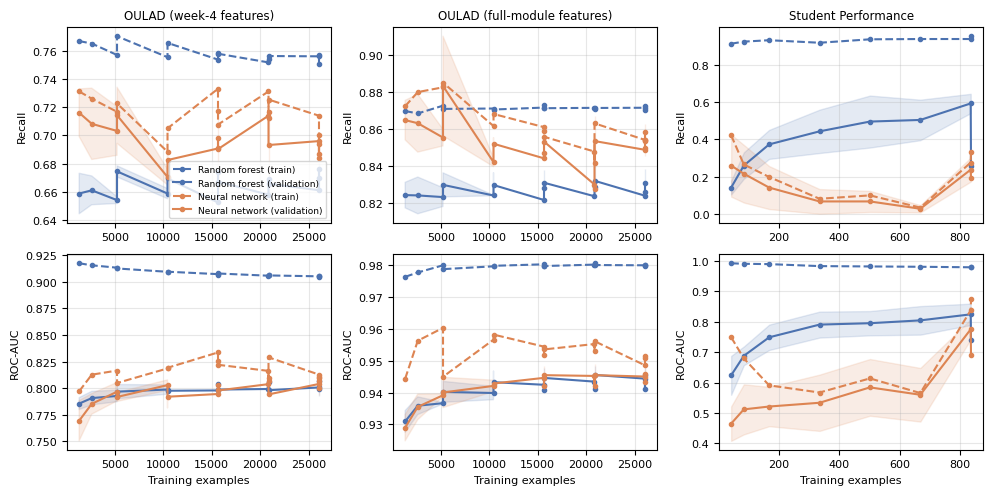

In [8]:
def plot_lc(ds_list, metrics=("Recall", "ROC-AUC"), fname="fig_learning_curves.pdf"):
    fig, axes = plt.subplots(len(metrics), len(ds_list), figsize=(3.3 * len(ds_list), 2.5 * len(metrics)), squeeze=False)
    colors = {"Random forest": "#4C72B0", "Neural network (MLP)": "#DD8452"}
    for j, ds in enumerate(ds_list):
        for i, met in enumerate(metrics):
            ax = axes[i, j]
            for m in MODELS:
                d = lc[(ds, m)].groupby(["split", "n_train"])[met].agg(["mean", "std"]).reset_index()
                for split, ls in [("train", "--"), ("validation", "-")]:
                    dd = d[d.split == split]
                    ax.plot(dd.n_train, dd["mean"], ls, marker="o", ms=3, color=colors[m],
                            label=f"{m.split(' (')[0]} ({split})")
                    if split == "validation":
                        ax.fill_between(dd.n_train, dd["mean"] - dd["std"], dd["mean"] + dd["std"], color=colors[m], alpha=0.15)
            ax.set_title(ds if i == 0 else "", fontsize=8.5)
            ax.set_ylabel(met); ax.set_xlabel("Training examples" if i == len(metrics) - 1 else "")
    axes[0, 0].legend(fontsize=6.5, loc="lower right")
    plt.tight_layout(); plt.savefig(f"{OUT}/{fname}", bbox_inches="tight"); plt.show()

plot_lc(["OULAD (week-4 features)", "OULAD (full-module features)", "Student Performance"])

In [9]:
# Numeric summary for the write-up: validation mean at smallest vs full size, and the train-validation gap at full size
summ = []
for (ds, m), d in lc.items():
    g = d.groupby(["split", "frac"])[["Recall", "F1", "ROC-AUC"]].mean()
    v_small, v_full, t_full = g.loc[("validation", SIZES.min())], g.loc[("validation", 1.0)], g.loc[("train", 1.0)]
    summ.append({"Dataset": ds, "Model": m,
                 "Val AUC @smallest": round(v_small["ROC-AUC"], 3), "Val AUC @full": round(v_full["ROC-AUC"], 3),
                 "Val recall @smallest": round(v_small["Recall"], 3), "Val recall @full": round(v_full["Recall"], 3),
                 "Train-val AUC gap @full": round(t_full["ROC-AUC"] - v_full["ROC-AUC"], 3)})
lc_summary = pd.DataFrame(summ); lc_summary.to_csv(f"{OUT}/learning_curve_summary.csv", index=False); lc_summary

,Dataset,Model,Val AUC @smallest,Val AUC @full,Val recall @smallest,Val recall @full,Train-val AUC gap @full
0,OULAD (week-4 features),Random forest,0.786,0.801,0.659,0.670,0.104
1,OULAD (week-4 features),Neural network (MLP),0.769,0.802,0.716,0.692,0.009
2,OULAD (full-module features),Random forest,0.931,0.944,0.824,0.828,0.035
3,OULAD (full-module features),Neural network (MLP),0.929,0.945,0.865,0.852,0.005
4,Student Performance,Random forest,0.624,0.808,0.143,0.526,0.172
5,Student Performance,Neural network (MLP),0.465,0.758,0.261,0.230,0.087


**Reading the curves.** A validation curve that is still rising at full size means more data would help (typical for the
1,044-row Student Performance set). A curve that plateaus early with a small train-validation gap means the model has reached the limit of the features.
A large persistent gap (random forest train AUC near 1.0) signals variance or overfitting. Watch the MLP recall band on Student Performance:
wide bands show that its Task 1 result depended heavily on which students landed in the test set.

## 5. Bias analysis with Microsoft Fairlearn

**Why Fairlearn:** it is native to scikit-learn pipelines, so the Task 1 models plug in unchanged. `MetricFrame` disaggregates *any* metric by
sensitive group, and it provides both assessment (disparity metrics) and mitigation (`ThresholdOptimizer`) in one tool. AIF360 offers similar metrics
but needs its own dataset wrapper, and What-If is built around TensorFlow and notebook widgets.

**Harm framing.** In an early-warning system the key quantities are:
- **False negative rate (FNR)**, the share of at-risk students who are missed and never offered help. This is an allocation harm.
- **False positive rate (FPR)**, the share of students flagged who were fine. This harm is stigma, since a flag can lower expectations.
- **Selection rate**, the share of each group flagged.

Equalised odds (equal TPR and FPR across groups) is therefore the primary criterion. Demographic parity is reported but is less appropriate, because
base rates genuinely differ between groups.

All predictions are **out-of-fold** from stratified group CV, so every student is scored by a model that never saw them.

In [10]:
# Out-of-fold predictions from the group-safe CV, random forest (the selected Task 1 model)
def oof(X, y, g, num, cat, model="Random forest"):
    prob = cross_val_predict(make_pipe(model, num, cat), X, y, groups=g, cv=cv_group, method="predict_proba")[:, 1]
    return prob, (prob >= 0.5).astype(int)

prob_o, pred_o = oof(X_o_early, y_o, groups_o, num_early, cat_o)   # deployable early-warning model
prob_c, pred_c = oof(X_c, y_c, groups_c, num_c, cat_c)

# Sensitive attributes (IMD collapsed to terciles, parental education to binary, for adequate group sizes)
imd_map = {"0-10%": "Most deprived (0-30%)", "10-20": "Most deprived (0-30%)", "20-30%": "Most deprived (0-30%)",
           "30-40%": "Middle (30-70%)", "40-50%": "Middle (30-70%)", "50-60%": "Middle (30-70%)", "60-70%": "Middle (30-70%)",
           "70-80%": "Least deprived (70-100%)", "80-90%": "Least deprived (70-100%)", "90-100%": "Least deprived (70-100%)",
           "Missing": "Missing"}
sens_o = pd.DataFrame({"gender": oulad["gender"], "disability": oulad["disability"], "age_band": oulad["age_band"],
                       "imd_tercile": oulad["imd_band"].map(imd_map).fillna("Missing"),
                       "highest_education": oulad["highest_education"]})
sens_c = pd.DataFrame({"sex": cortez["sex"], "address": cortez["address"].map({"U": "Urban", "R": "Rural"}),
                       "school": cortez["school"],
                       "mother_edu": np.where(cortez["Medu"] >= 3, "Secondary+", "Below secondary")})

METRICS = {"n": count, "base_rate": lambda yt, yp: yt.mean(), "selection_rate": selection_rate,
           "recall(TPR)": recall_score, "FNR": false_negative_rate, "FPR": false_positive_rate,
           "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0)}

def audit(y, pred, sens, label):
    frames, summary = {}, []
    for col in sens.columns:
        mf = MetricFrame(metrics=METRICS, y_true=y, y_pred=pred, sensitive_features=sens[col])
        frames[col] = mf
        summary.append({"Dataset": label, "Attribute": col, "Groups": sens[col].nunique(),
                        "Recall gap (max-min)": round(mf.difference()["recall(TPR)"], 3),
                        "FPR gap": round(mf.difference()["FPR"], 3),
                        "Recall ratio (min/max)": round(mf.ratio()["recall(TPR)"], 3),
                        "Demographic parity diff": round(demographic_parity_difference(y, pred, sensitive_features=sens[col]), 3),
                        "Equalised odds diff": round(equalized_odds_difference(y, pred, sensitive_features=sens[col]), 3)})
        print(f"\n=== {label}: {col} ===")
        print(mf.by_group.round(3).to_string())
    return frames, pd.DataFrame(summary)

frames_o, fair_o = audit(y_o, pred_o, sens_o, "OULAD (week-4 RF)")
frames_c, fair_c = audit(y_c, pred_c, sens_c, "Student Performance (RF)")
fair_summary = pd.concat([fair_o, fair_c]); fair_summary.to_csv(f"{OUT}/fairness_summary.csv", index=False)
fair_summary


=== OULAD (week-4 RF): gender ===
              n  base_rate  selection_rate  recall(TPR)    FNR    FPR  precision
gender                                                                          
F       14718.0      0.516           0.427        0.637  0.363  0.203       0.77
M       17875.0      0.538           0.479        0.695  0.305  0.228       0.78

=== OULAD (week-4 RF): disability ===
                  n  base_rate  selection_rate  recall(TPR)    FNR    FPR  precision
disability                                                                          
N           29429.0      0.518           0.440        0.658  0.342  0.207      0.774
Y            3164.0      0.619           0.596        0.763  0.237  0.326      0.791

=== OULAD (week-4 RF): age_band ===
                n  base_rate  selection_rate  recall(TPR)    FNR    FPR  precision
age_band                                                                          
0-35      22944.0      0.550           0.497        0.699  

,Dataset,Attribute,Groups,Recall gap (max-min),FPR gap,Recall ratio (min/max),Demographic parity diff,Equalised odds diff
0,OULAD (week-4 RF),gender,2,0.058,0.025,0.917,0.053,0.058
1,OULAD (week-4 RF),disability,2,0.105,0.120,0.862,0.156,0.120
2,OULAD (week-4 RF),age_band,3,0.229,0.154,0.673,0.257,0.229
3,OULAD (week-4 RF),imd_tercile,4,0.271,0.204,0.632,0.347,0.271
4,OULAD (week-4 RF),highest_education,5,0.238,0.224,0.685,0.356,0.238
0,Student Performance (RF),sex,2,0.048,0.020,0.912,0.003,0.048
1,Student Performance (RF),address,2,0.049,0.098,0.913,0.111,0.098
2,Student Performance (RF),school,2,0.117,0.112,0.805,0.159,0.117
3,Student Performance (RF),mother_edu,2,0.170,0.125,0.717,0.157,0.170


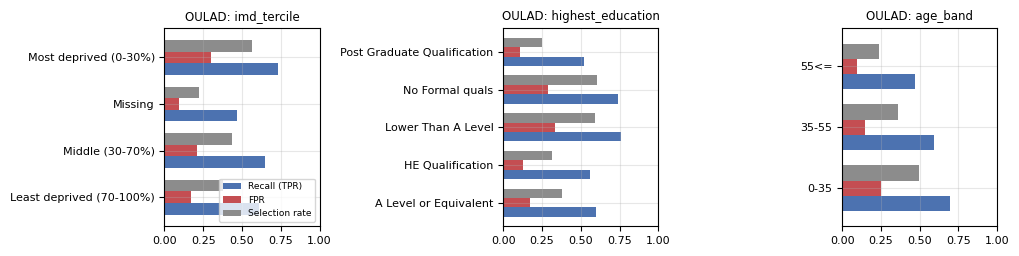

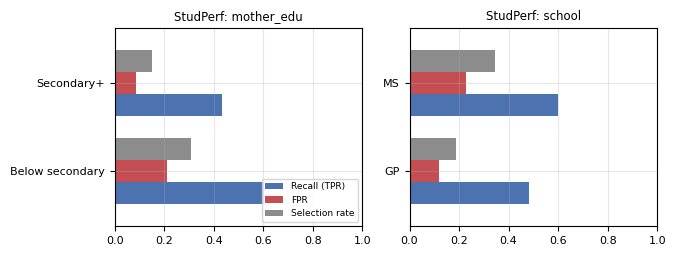

In [11]:
# Figure: recall and FPR by group for the attributes with the largest equalised-odds difference
def plot_groups(frames, attrs, title, fname):
    fig, axes = plt.subplots(1, len(attrs), figsize=(3.4 * len(attrs), 2.6), squeeze=False)
    for ax, a in zip(axes[0], attrs):
        bg = frames[a].by_group[["recall(TPR)", "FPR", "selection_rate"]]
        bg.plot.barh(ax=ax, width=0.75, color=["#4C72B0", "#C44E52", "#8C8C8C"], legend=False)
        ax.set_title(f"{title}: {a}", fontsize=8.5); ax.set_xlim(0, 1); ax.set_ylabel("")
    axes[0, 0].legend(["Recall (TPR)", "FPR", "Selection rate"], fontsize=6.5, loc="lower right")
    plt.tight_layout(); plt.savefig(f"{OUT}/{fname}", bbox_inches="tight"); plt.show()

top_o = fair_o.sort_values("Equalised odds diff", ascending=False)["Attribute"].head(3).tolist()
top_c = fair_c.sort_values("Equalised odds diff", ascending=False)["Attribute"].head(2).tolist()
plot_groups(frames_o, top_o, "OULAD", "fig_fairness_oulad.pdf")
plot_groups(frames_c, top_c, "StudPerf", "fig_fairness_studperf.pdf")

### 5.1 Does removing sensitive attributes fix it? ("fairness through unawareness")

Task 1 fed gender, disability, age band and deprivation directly into the model. Here those are dropped and the disparities recomputed.
If gaps persist, bias is flowing through **proxies** (for example, engagement patterns correlated with disability or deprivation), and simply deleting
columns is not a remedy.

In [12]:
aware_drop_o = ["gender", "disability", "age_band", "imd_band"]
aware_drop_c = ["sex", "address", "Medu", "Fedu"]
cat_o_u = [c for c in cat_o if c not in aware_drop_o]
num_c_u = [c for c in num_c if c not in aware_drop_c]; cat_c_u = [c for c in cat_c if c not in aware_drop_c]

prob_o_u, pred_o_u = oof(oulad[num_early + cat_o_u], y_o, groups_o, num_early, cat_o_u)
prob_c_u, pred_c_u = oof(cortez[num_c_u + cat_c_u], y_c, groups_c, num_c_u, cat_c_u)

rows = []
for label, y, (pa, pu), (ba, bu), sens in [("OULAD", y_o, (pred_o, pred_o_u), (prob_o, prob_o_u), sens_o),
                                          ("Student Performance", y_c, (pred_c, pred_c_u), (prob_c, prob_c_u), sens_c)]:
    for col in sens.columns:
        rows.append({"Dataset": label, "Attribute": col,
                     "EO diff (with attrs)": round(equalized_odds_difference(y, pa, sensitive_features=sens[col]), 3),
                     "EO diff (unaware)": round(equalized_odds_difference(y, pu, sensitive_features=sens[col]), 3)})
    rows.append({"Dataset": label, "Attribute": "[overall ROC-AUC]",
                 "EO diff (with attrs)": round(roc_auc_score(y, ba), 3), "EO diff (unaware)": round(roc_auc_score(y, bu), 3)})
unaware = pd.DataFrame(rows); unaware.to_csv(f"{OUT}/unawareness_test.csv", index=False); unaware

,Dataset,Attribute,EO diff (with attrs),EO diff (unaware)
0,OULAD,gender,0.058,0.060
1,OULAD,disability,0.120,0.032
2,OULAD,age_band,0.229,0.184
3,OULAD,imd_tercile,0.271,0.146
4,OULAD,highest_education,0.238,0.262
5,OULAD,[overall ROC-AUC],0.801,0.795
6,Student Performance,sex,0.048,0.075
7,Student Performance,address,0.098,0.073
8,Student Performance,school,0.117,0.100
9,Student Performance,mother_edu,0.170,0.091


### 5.2 Mitigation: ThresholdOptimizer (equalised odds)

A post-processing mitigation. It learns group-specific thresholds on a training fold and is evaluated on a held-out, student-disjoint fold.
The point is to show the **fairness-accuracy trade-off** rather than to endorse group-specific thresholds. Using a protected attribute at decision
time raises its own legal and ethical questions, which are discussed in the report.

In [13]:
def mitigate(X, y, g, num, cat, sens_col, label):
    tr, te = next(StratifiedGroupKFold(K, shuffle=True, random_state=RANDOM_STATE).split(X, y, g))
    base = make_pipe("Random forest", num, cat).fit(X.iloc[tr], y.iloc[tr])
    to = ThresholdOptimizer(estimator=base, constraints="equalized_odds", objective="balanced_accuracy_score",
                            prefit=True, predict_method="predict_proba")
    to.fit(X.iloc[tr], y.iloc[tr], sensitive_features=sens_col.iloc[tr])
    yb = base.predict(X.iloc[te]); ym = to.predict(X.iloc[te], sensitive_features=sens_col.iloc[te], random_state=RANDOM_STATE)
    yt, s = y.iloc[te], sens_col.iloc[te]
    out = []
    for name, yp in [("Unmitigated RF", yb), ("ThresholdOptimizer (EO)", ym)]:
        out.append({"Dataset": label, "Attribute": sens_col.name, "Model": name,
                    "Accuracy": round(accuracy_score(yt, yp), 3), "Recall": round(recall_score(yt, yp), 3),
                    "EO diff": round(equalized_odds_difference(yt, yp, sensitive_features=s), 3),
                    "Min group recall": round(MetricFrame(metrics=recall_score, y_true=yt, y_pred=yp, sensitive_features=s).group_min(), 3)})
    return out

mit = pd.DataFrame(mitigate(X_o_early, y_o, groups_o, num_early, cat_o, sens_o[top_o[0]], "OULAD")
                   + mitigate(X_c, y_c, groups_c, num_c, cat_c, sens_c[top_c[0]], "Student Performance"))
mit.to_csv(f"{OUT}/mitigation.csv", index=False); mit

,Dataset,Attribute,Model,Accuracy,Recall,EO diff,Min group recall
0,OULAD,imd_tercile,Unmitigated RF,0.727,0.676,0.296,0.453
1,OULAD,imd_tercile,ThresholdOptimizer (EO),0.715,0.761,0.149,0.625
2,Student Performance,mother_edu,Unmitigated RF,0.799,0.630,0.158,0.588
3,Student Performance,mother_edu,ThresholdOptimizer (EO),0.780,0.587,0.095,0.552


## 6. Exports for the LaTeX report

All CSVs and PDF figures are in `part2_outputs/`. Upload the PDFs to Overleaf and `\includegraphics` them.
Paste the printed tables (or share the CSVs) back into the chat so the Part 2 write-up can quote the real numbers.

In [14]:
for f in sorted(os.listdir(OUT)): print(f)
print("\n=== CV comparison ===");        print(cv_table.to_string(index=False))
print("\n=== Learning-curve summary ==="); print(lc_summary.to_string(index=False))
print("\n=== Fairness summary ===");      print(fair_summary.to_string(index=False))
print("\n=== Unawareness test ===");      print(unaware.to_string(index=False))
print("\n=== Mitigation ===");            print(mit.to_string(index=False))

.ipynb_checkpoints
cv_comparison.csv
fairness_summary.csv
fig_fairness_oulad.pdf
fig_fairness_studperf.pdf
fig_learning_curves.pdf
learning_curve_summary.csv
learning_curves.csv
mitigation.csv
unawareness_test.csv

=== CV comparison ===
            Dataset             Features                Model                  Design      Accuracy     Precision        Recall            F1       ROC-AUC
              OULAD Full-module features        Random forest      Single 80/20 split         0.878         0.927         0.835         0.879         0.947
              OULAD Full-module features        Random forest       Stratified 5-fold 0.874 ± 0.002 0.924 ± 0.004 0.830 ± 0.005 0.874 ± 0.002 0.945 ± 0.003
              OULAD Full-module features        Random forest Stratified group 5-fold 0.874 ± 0.004 0.925 ± 0.005 0.828 ± 0.006 0.874 ± 0.005 0.944 ± 0.002
              OULAD Full-module features Neural network (MLP)      Single 80/20 split         0.881         0.906         0.864         0.8

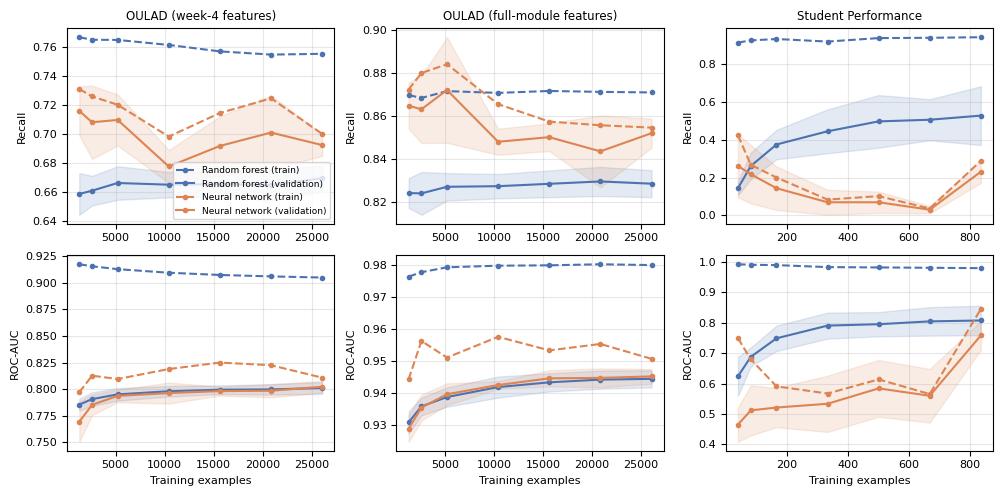

In [15]:
d = pd.read_csv(f"{OUT}/learning_curves.csv")
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
dsets = ["OULAD (week-4 features)", "OULAD (full-module features)", "Student Performance"]
colors = {"Random forest": "#4C72B0", "Neural network (MLP)": "#DD8452"}
for j, ds in enumerate(dsets):
    for i, met in enumerate(["Recall", "ROC-AUC"]):
        ax = axes[i, j]
        for m in MODELS:
            g = (d[(d.Dataset == ds) & (d.Model == m)]
                 .groupby(["split", "frac"]).agg(n=("n_train", "mean"), mean=(met, "mean"), std=(met, "std"))
                 .reset_index())
            for split, ls in [("train", "--"), ("validation", "-")]:
                s = g[g.split == split]
                ax.plot(s.n, s["mean"], ls, marker="o", ms=3, color=colors[m], label=f"{m.split(' (')[0]} ({split})")
                if split == "validation":
                    ax.fill_between(s.n, s["mean"] - s["std"], s["mean"] + s["std"], color=colors[m], alpha=0.15)
        ax.set_title(ds if i == 0 else "", fontsize=8.5); ax.set_ylabel(met)
        ax.set_xlabel("Training examples" if i == 1 else "")
axes[0, 0].legend(fontsize=6.5, loc="lower right")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_learning_curves.pdf", bbox_inches="tight"); plt.show()